In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageOps

def load_points_from_json(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)
    im1_pts = np.array(data["im1Points"], dtype=float)
    im2_pts = np.array(data["im2Points"], dtype=float)
    return im1_pts, im2_pts, data.get("im1_name"), data.get("im2_name")

def _safe_load_image(path, fallback_size, apply_exif_orientation=True):
    p = Path(path) if path is not None else None
    if p is not None and p.exists():
        img = Image.open(p).convert("RGB")
        if apply_exif_orientation:
            img = ImageOps.exif_transpose(img)
        return np.asarray(img)

    h = int(max(100, fallback_size[1]))
    w = int(max(100, fallback_size[0]))
    return np.ones((h, w, 3), dtype=np.float32)

def visualize_correspondences(img1_path, img2_path, im1_pts, im2_pts, title=None, show_lines=True):
    w1 = max(int(np.max(im1_pts[:,0])) + 10, 100)
    h1 = max(int(np.max(im1_pts[:,1])) + 10, 100)
    w2 = max(int(np.max(im2_pts[:,0])) + 10, 100)
    h2 = max(int(np.max(im2_pts[:,1])) + 10, 100)

    I1 = _safe_load_image(img1_path, (w1, h1))
    I2 = _safe_load_image(img2_path, (w2, h2))

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)

    ax1.imshow(I1)
    # ax1.scatter(im1_pts[:,0], im1_pts[:,1], s=30, marker='o')
    # for i, (x, y) in enumerate(im1_pts):
    #     ax1.text(x+5, y-5, str(i), fontsize=12)
    ax1.set_title("Image 1 with points")
    ax1.axis("off")

    ax2.imshow(I2)
    # ax2.scatter(im2_pts[:,0], im2_pts[:,1], s=30, marker='o')
    # for i, (x, y) in enumerate(im2_pts):
    #     ax2.text(x+5, y-5, str(i), fontsize=12)
    ax2.set_title("Image 2 with points")
    ax2.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    if show_lines:
        H_cat = max(I1.shape[0], I2.shape[0])
        W_cat = I1.shape[1] + I2.shape[1]
        canvas = np.ones((H_cat, W_cat, 3), dtype=np.float32)
        canvas[:I1.shape[0], :I1.shape[1]] = I1/255.0 if I1.max()>1 else I1
        canvas[:I2.shape[0], I1.shape[1]:I1.shape[1]+I2.shape[1]] = I2/255.0 if I2.max()>1 else I2

        plt.figure(figsize=(12, 6))
        plt.imshow(canvas)
        offset = I1.shape[1]
        plt.scatter(im1_pts[:,0], im1_pts[:,1], s=22)
        plt.scatter(im2_pts[:,0] + offset, im2_pts[:,1], s=22)
        for i in range(im1_pts.shape[0]):
            x1, y1 = im1_pts[i]
            x2, y2 = im2_pts[i]
            plt.plot([x1, x2 + offset], [y1, y2], linewidth=1)
            plt.text(x1+4, y1-4, str(i), fontsize=12, color='orange')
            plt.text(x2+offset+4, y2-4, str(i), fontsize=12, color='orange')
        plt.axis("off")
        # plt.title("Side-by-side with correspondence lines")
        plt.tight_layout()
        plt.show()

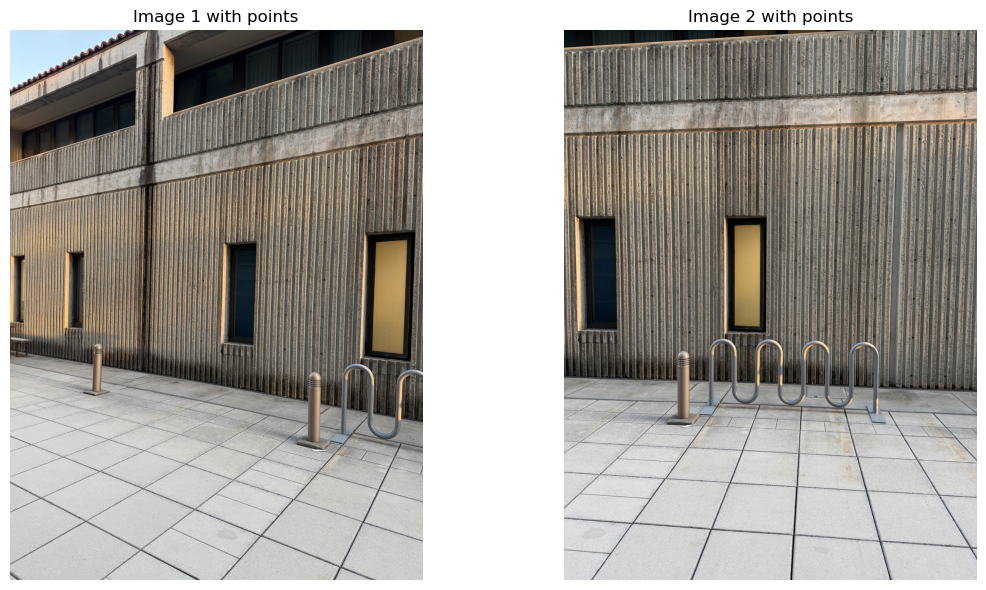

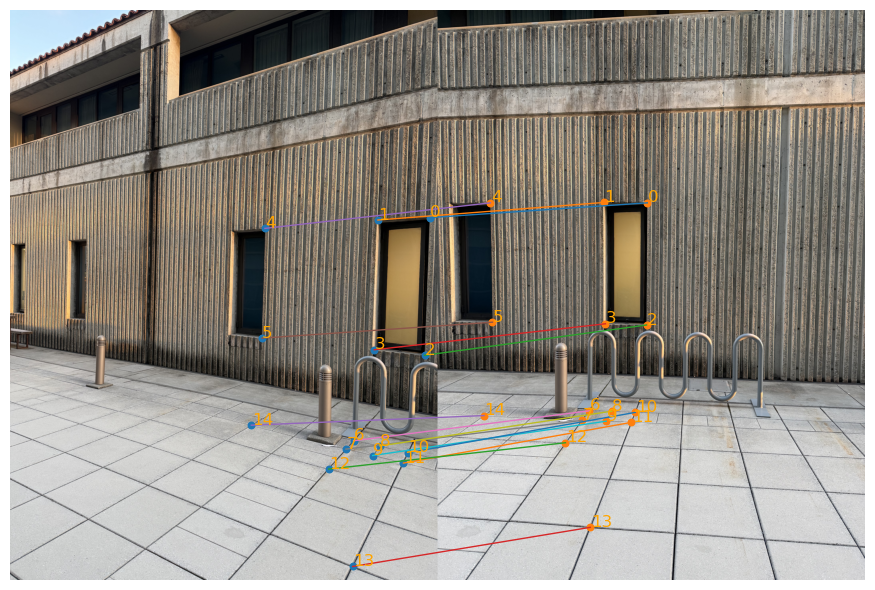

In [2]:
# json_path = "building1/bo1_bo3.json" 
# im1_pts, im2_pts, im1_name, im2_name = load_points_from_json(json_path)

# img1_path = "building1/bo1.jpg"
# img2_path = "building1/bo3.jpg"

# json_path = "building2/bt2_bt4.json" 
# im1_pts, im2_pts, im1_name, im2_name = load_points_from_json(json_path)

# img1_path = "building2/bt2.jpg"
# img2_path = "building2/bt4.jpg"

json_path = "wall/w1_w3.json" 
im1_pts, im2_pts, im1_name, im2_name = load_points_from_json(json_path)

img1_path = "wall/w1.jpg"
img2_path = "wall/w3.jpg"

visualize_correspondences(img1_path, img2_path, im1_pts, im2_pts)

In [3]:
def computeH(im1_pts, im2_pts):
    im1_pts = np.asarray(im1_pts, dtype=float)
    im2_pts = np.asarray(im2_pts, dtype=float)
    n = im1_pts.shape[0]

    x,  y  = im1_pts[:,0], im1_pts[:,1]
    xp, yp = im2_pts[:,0], im2_pts[:,1]

    A = np.zeros((2*n, 8), dtype=float)
    b = np.zeros((2*n, 1), dtype=float)

    A[0::2, 0] = -x
    A[0::2, 1] = -y
    A[0::2, 2] = -1
    A[0::2, 6] =  x * xp
    A[0::2, 7] =  y * xp
    b[0::2, 0] = -xp

    A[1::2, 3] = -x
    A[1::2, 4] = -y
    A[1::2, 5] = -1
    A[1::2, 6] =  x * yp
    A[1::2, 7] =  y * yp
    b[1::2, 0] = -yp

    h, *_ = np.linalg.lstsq(A, b, rcond=None)
    h = h.flatten()

    H = np.array([[h[0], h[1], h[2]],
                  [h[3], h[4], h[5]],
                  [h[6], h[7], 1.0]], dtype=float)

    if abs(H[2,2]) > 1e-12:
        H /= H[2,2]
    return H

def computeH_normalized(im1_pts, im2_pts):
    im1_pts = np.asarray(im1_pts, float)
    im2_pts = np.asarray(im2_pts, float)
    assert im1_pts.shape == im2_pts.shape and im1_pts.shape[1] == 2
    n = im1_pts.shape[0]; assert n >= 4

    def _norm(pts):
        m = pts.mean(axis=0)
        pts_c = pts - m
        s = np.sqrt(2.0) / (np.sqrt((pts_c**2).sum(1)).mean() + 1e-12)
        T = np.array([[s,0,-s*m[0]],[0,s,-s*m[1]],[0,0,1]], float)
        ph = np.hstack([pts, np.ones((n,1))])
        pn = (T @ ph.T).T
        return T, pn[:, :2] / pn[:, [2]]

    T1, p1 = _norm(im1_pts); T2, p2 = _norm(im2_pts)

    A = []
    for (x,y),(xp,yp) in zip(p1,p2):
        A.append([-x,-y,-1, 0,0,0, x*xp, y*xp, xp])
        A.append([ 0,0,0,-x,-y,-1, x*yp, y*yp, yp])
    A = np.asarray(A, float)
    _, _, Vt = np.linalg.svd(A)
    Hn = Vt[-1].reshape(3,3)

    H = np.linalg.inv(T2) @ Hn @ T1
    return H / H[2,2]

def project_points(H, pts):
    pts = np.asarray(pts, float)
    P = np.hstack([pts, np.ones((pts.shape[0], 1))])   # n×3
    Q = (H @ P.T).T                                    # n×3
    return Q[:, :2] / Q[:, [2]]

def reproj_rmse(im1_pts, im2_pts, H):
    fwd = project_points(H, im1_pts)
    bwd = project_points(np.linalg.inv(H), im2_pts)
    rmse_f = np.sqrt(np.mean(np.sum((fwd - im2_pts)**2, axis=1)))
    rmse_b = np.sqrt(np.mean(np.sum((bwd - im1_pts)**2, axis=1)))
    return rmse_f, rmse_b

def ransac_H(im1_pts, im2_pts, iters=2000, thresh=3.0):
    im1_pts = np.asarray(im1_pts, float)
    im2_pts = np.asarray(im2_pts, float)
    n = im1_pts.shape[0]; best_inl = []; best_H = None
    rng = np.random.default_rng(0)

    def symmetric_error(H):
        p12 = project_points(H, im1_pts)
        p21 = project_points(np.linalg.inv(H), im2_pts)
        e = np.sqrt(((p12 - im2_pts)**2).sum(1)) + np.sqrt(((p21 - im1_pts)**2).sum(1))
        return e

    for _ in range(iters):
        idx = rng.choice(n, 4, replace=False)
        Hc = computeH_normalized(im1_pts[idx], im2_pts[idx])
        e = symmetric_error(Hc)
        inl = np.where(e < thresh)[0]
        if inl.size > len(best_inl):
            best_inl = inl
            best_H = Hc

    if len(best_inl) >= 4:
        H_refined = computeH_normalized(im1_pts[best_inl], im2_pts[best_inl])
        return H_refined, best_inl
    else:
        return best_H, best_inl

In [4]:
def _to_h(pxy):
    ones = np.ones((pxy.shape[0], 1), dtype=np.float64)
    return np.hstack([pxy.astype(np.float64), ones])

def _from_h(ph):
    w = ph[:, [2]]
    return ph[:, :2] / (w + 1e-12)

def _warp_bbox(H, h, w):
    corners = np.array([[0, 0],
                        [w-1, 0],
                        [0, h-1],
                        [w-1, h-1]], dtype=np.float64)
    warped = _from_h((_to_h(corners) @ H.T))  # (4,2)

    xmin = np.floor(warped[:,0].min())
    xmax = np.ceil (warped[:,0].max())
    ymin = np.floor(warped[:,1].min())
    ymax = np.ceil (warped[:,1].max())

    Tx, Ty = -xmin, -ymin
    T = np.array([[1, 0, Tx],
                  [0, 1, Ty],
                  [0, 0, 1 ]], dtype=np.float64)
    return xmin, ymin, xmax, ymax, T

def _grid_xy(W, H):
    xs = np.arange(W, dtype=np.float64)
    ys = np.arange(H, dtype=np.float64)
    xx, yy = np.meshgrid(xs, ys)
    return np.stack([xx.ravel(), yy.ravel()], axis=1)

def _sample_nn(img, x, y):
    h, w = img.shape[:2]
    xi = np.rint(x).astype(int)
    yi = np.rint(y).astype(int)
    valid = (xi >= 0) & (xi < w) & (yi >= 0) & (yi < h)
    out = np.zeros((x.size, img.shape[2] if img.ndim==3 else 1), dtype=img.dtype)
    if img.ndim == 2:
        out = out[:,0]
    out[valid] = img[yi[valid], xi[valid]]
    return out, valid

def _sample_bilinear(img, x, y):
    h, w = img.shape[:2]
    x0 = np.floor(x).astype(int)
    y0 = np.floor(y).astype(int)
    x1 = x0 + 1
    y1 = y0 + 1

    valid = (x0 >= 0) & (x1 < w) & (y0 >= 0) & (y1 < h)

    dx = (x - x0)
    dy = (y - y0)

    C = img.shape[2] if img.ndim == 3 else 1
    out = np.zeros((x.size, C), dtype=np.float64)

    if np.any(valid):
        x0v, x1v = x0[valid], x1[valid]
        y0v, y1v = y0[valid], y1[valid]
        dxv, dyv = dx[valid][:, None], dy[valid][:, None]

        Q00 = img[y0v, x0v]
        Q10 = img[y0v, x1v]
        Q01 = img[y1v, x0v]
        Q11 = img[y1v, x1v]

        out_v = (Q00 * (1-dxv) * (1-dyv) +
                 Q10 * (dxv)   * (1-dyv) +
                 Q01 * (1-dxv) * (dyv)   +
                 Q11 * (dxv)   * (dyv))
        out[valid] = out_v

    if img.ndim == 2:
        out = out[:,0]
    return out.astype(img.dtype), valid

def _warp_core(im, H, method="bilinear", fill_value=0):
    h, w = im.shape[:2]
    xmin, ymin, xmax, ymax, T = _warp_bbox(H, h, w)
    Ht = T @ H
    Hinv = np.linalg.inv(Ht)

    out_W = int(max(1, xmax - xmin + 1))
    out_H = int(max(1, ymax - ymin + 1))

    grid = _grid_xy(out_W, out_H)
    src = _from_h((_to_h(grid) @ Hinv.T))
    xs, ys = src[:,0], src[:,1]

    if method == "nearest":
        samp, valid = _sample_nn(im, xs, ys)
    elif method == "bilinear":
        samp, valid = _sample_bilinear(im, xs, ys)
    else:
        raise ValueError("method must be 'nearest' or 'bilinear'")

    C = im.shape[2] if im.ndim == 3 else 1
    warped = np.full((out_H, out_W, C), fill_value, dtype=im.dtype)
    warped.reshape(-1, C)[valid] = samp.reshape(-1, C)[valid]
    if C == 1:
        warped = warped[...,0]

    alpha = np.zeros((out_H, out_W), dtype=np.uint8)
    alpha.reshape(-1)[valid] = 255

    offset = (int(np.floor(xmin)), int(np.floor(ymin)))
    return warped, alpha, offset

def warpImageNearestNeighbor(im, H, fill_value=0):
    return _warp_core(im, H, method="nearest", fill_value=fill_value)

def warpImageBilinear(im, H, fill_value=0):
    return _warp_core(im, H, method="bilinear", fill_value=fill_value)


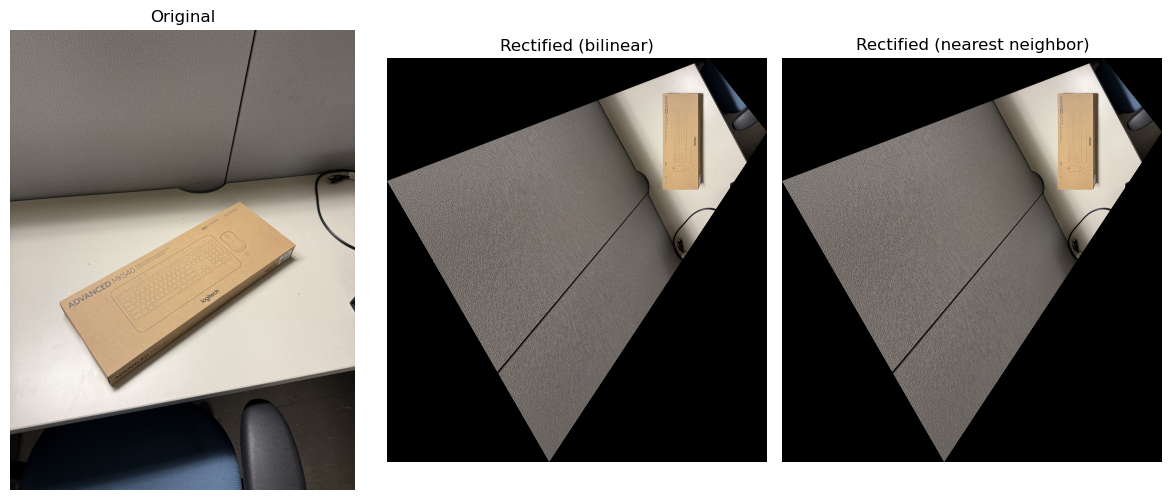

In [5]:
img_path = "rectification/box.jpg"
json_path = "rectification/box.json"
scale = 40.0

with open(json_path, "r") as f:
    data = json.load(f)
im1_pts = np.array(data["im1Points"], dtype=float) 
im2_pts = np.array(data["im2Points"], dtype=float)

im2_pts_scaled = im2_pts * scale

H_rect = computeH(im1_pts, im2_pts_scaled)

img = Image.open(img_path).convert("RGB")
img = ImageOps.exif_transpose(img)
im = np.asarray(img)

rectified1, alpha1, offset1 = warpImageBilinear(im, H_rect, fill_value=0)
rectified2, alpha2, offset2 = warpImageNearestNeighbor(im, H_rect, fill_value=0)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(im); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(rectified1); plt.title(f"Rectified (bilinear)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(rectified2); plt.title(f"Rectified (nearest neighbor)"); plt.axis("off")
plt.tight_layout(); plt.show()

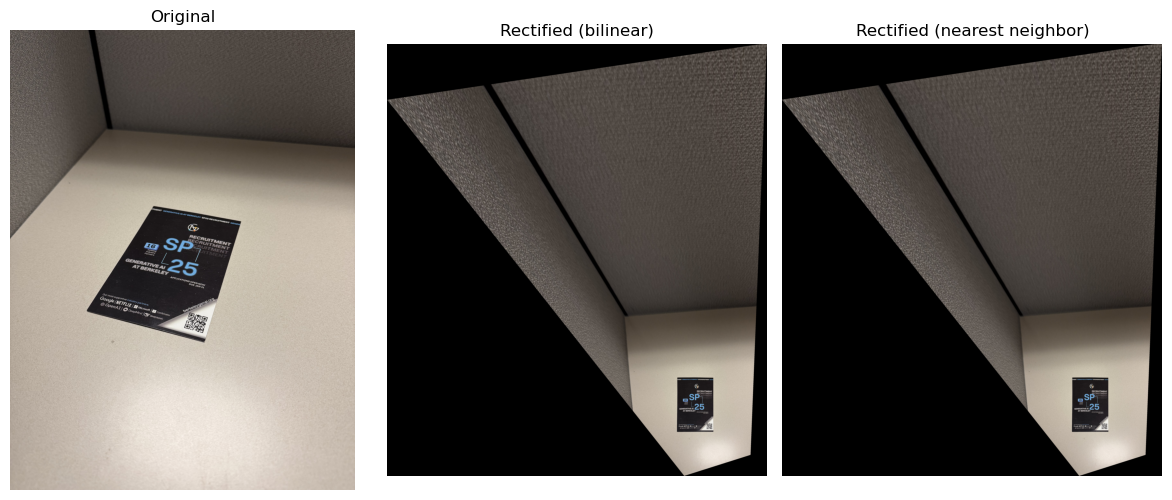

In [6]:
img_path = "rectification/flyer.jpg"
json_path = "rectification/flyer.json"
scale = 40.0

with open(json_path, "r") as f:
    data = json.load(f)
im1_pts = np.array(data["im1Points"], dtype=float) 
im2_pts = np.array(data["im2Points"], dtype=float)

im2_pts_scaled = im2_pts * scale

H_rect = computeH(im1_pts, im2_pts_scaled)

img = Image.open(img_path).convert("RGB")
img = ImageOps.exif_transpose(img)
im = np.asarray(img)

rectified1, alpha1, offset1 = warpImageBilinear(im, H_rect, fill_value=0)
rectified2, alpha2, offset2 = warpImageNearestNeighbor(im, H_rect, fill_value=0)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(im); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(rectified1); plt.title(f"Rectified (bilinear)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(rectified2); plt.title(f"Rectified (nearest neighbor)"); plt.axis("off")
plt.tight_layout(); plt.show()

In [7]:
def _box_blur_1d(arr, k):
    if k <= 1:
        return arr.astype(np.float64, copy=False)

    k = int(k) | 1
    r = k // 2

    pad = np.pad(arr, ((0, 0), (r, r)), mode='edge').astype(np.float64)
    integral = np.cumsum(pad, axis=1)
    integral = np.concatenate([np.zeros((arr.shape[0], 1), dtype=np.float64), integral], axis=1)

    out = (integral[:, k:] - integral[:, :-k]) / k
    return out

def _box_blur_2d(img, k):
    if k <= 1:
        return img.astype(np.float64, copy=False)
    tmp = _box_blur_1d(img, k)
    tmp = _box_blur_1d(tmp.T, k).T
    return tmp

def _soft_alpha(alpha_uint8, ksize=31, gamma=1.0):
    a = alpha_uint8.astype(np.float32) / 255.0
    if a.max() == 0:
        return a

    k = int(max(1, ksize)) | 1
    blurred = _box_blur_2d(a, k)

    if blurred.max() > 1e-8:
        blurred = blurred / blurred.max()
    blurred *= (a > 0).astype(np.float32)

    if gamma != 1.0:
        blurred = np.power(blurred, gamma)
    return blurred

def _accumulate(canvas_sum, canvas_wsum, patch, weight, top, left):
    H, W = patch.shape[:2]
    cs = canvas_sum[top:top+H, left:left+W]
    cw = canvas_wsum[top:top+H, left:left+W]
    if patch.ndim == 2:  patch = patch[..., None]
    if weight.ndim == 2: weight = weight[..., None]
    cs += patch.astype(np.float64) * weight
    cw += weight

def blend_pair(im1, im2, H_1to2, warp_func, feather=True, falloff=60, gamma=1.0, bg=0):
    w1, a1, off1 = warp_func(im1, H_1to2, fill_value=bg)
    offx, offy = off1
    h2, w2 = im2.shape[:2]

    minx = min(0, offx); miny = min(0, offy)
    maxx = max(w2, offx + w1.shape[1]); maxy = max(h2, offy + w1.shape[0])
    W = maxx - minx; H = maxy - miny

    canvas_sum  = np.zeros((H, W, 3), dtype=np.float64)
    canvas_wsum = np.zeros((H, W, 3), dtype=np.float64)

    im2_alpha = np.full((h2, w2), 255, dtype=np.uint8)
    w2_soft = _soft_alpha(im2_alpha, ksize=falloff, gamma=gamma) if feather else (im2_alpha/255.0)
    _accumulate(canvas_sum, canvas_wsum, im2, w2_soft, top=-miny, left=-minx)

    w1_soft = _soft_alpha(a1, ksize=falloff, gamma=gamma) if feather else (a1/255.0)
    _accumulate(canvas_sum, canvas_wsum, w1, w1_soft, top=offy - miny, left=offx - minx)

    eps = 1e-6
    mosaic = (canvas_sum / np.maximum(canvas_wsum, eps)).astype(np.uint8)
    return mosaic

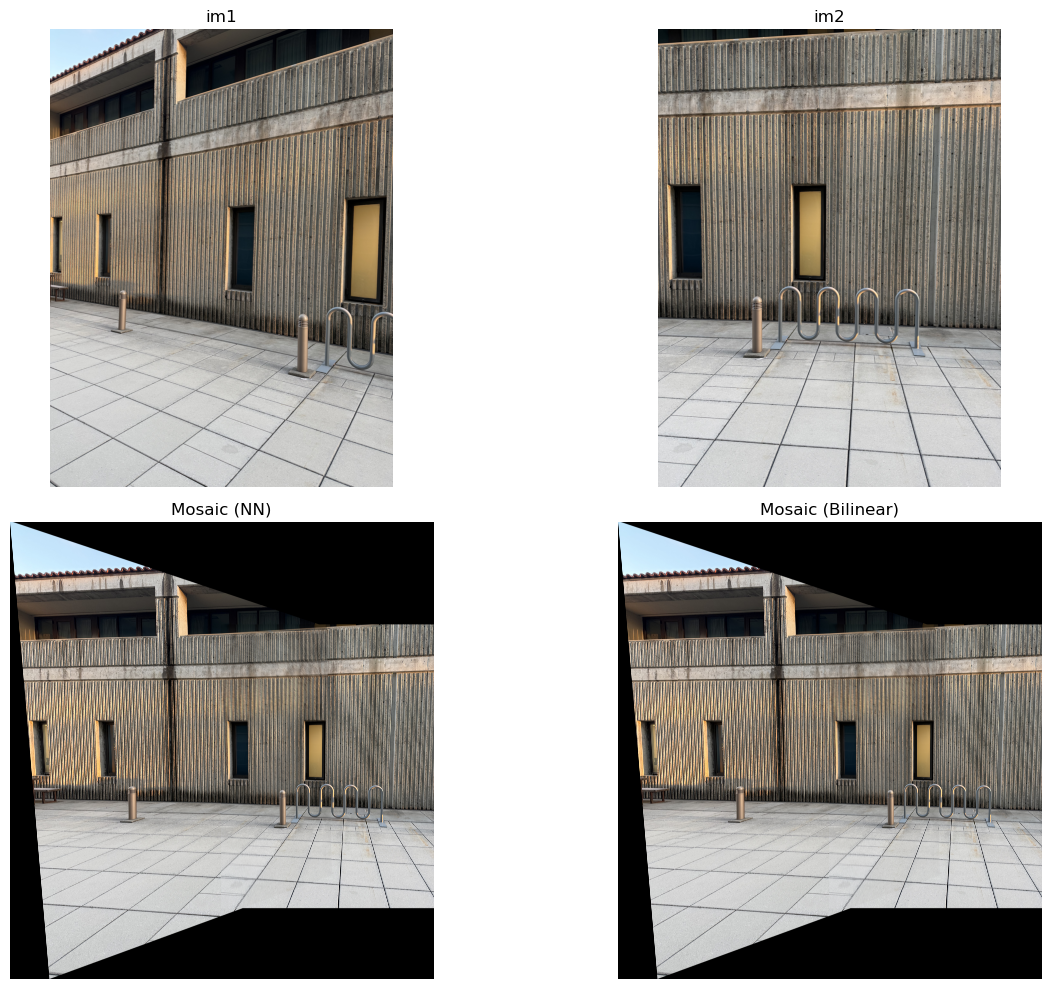

In [8]:
# json_path = "KitchenSpace/k1_k2.json" 
# im1_pts, im2_pts, im1_name, im2_name = load_points_from_json(json_path)

# img1_path = "KitchenSpace/k1.jpg" 
# img2_path = "KitchenSpace/k2.jpg"

# json_path = "building1/bo1_bo3.json" 
# im1_pts, im2_pts, im1_name, im2_name = load_points_from_json(json_path)

# img1_path = "building1/bo1.jpg"
# img2_path = "building1/bo3.jpg"

# json_path = "building2/bt2_bt4.json" 
# im1_pts, im2_pts, im1_name, im2_name = load_points_from_json(json_path)

# img1_path = "building2/bt2.jpg"
# img2_path = "building2/bt4.jpg"

json_path = "wall/w1_w3.json" 
im1_pts, im2_pts, im1_name, im2_name = load_points_from_json(json_path)

img1_path = "wall/w1.jpg"
img2_path = "wall/w3.jpg"

w1 = int(np.ceil(im1_pts[:,0].max())+10); h1 = int(np.ceil(im1_pts[:,1].max())+10)
w2 = int(np.ceil(im2_pts[:,0].max())+10); h2 = int(np.ceil(im2_pts[:,1].max())+10)

im1 = _safe_load_image(img1_path, (w1, h1))
im2 = _safe_load_image(img2_path, (w2, h2))

H_1to2 = computeH_normalized(im1_pts, im2_pts)

mosaic_nn  = blend_pair(im1, im2, H_1to2, warp_func=warpImageNearestNeighbor, feather=True, falloff=60, gamma=1.0)
mosaic_bil = blend_pair(im1, im2, H_1to2, warp_func=warpImageBilinear,     feather=True, falloff=60, gamma=1.0)



plt.figure(figsize=(14,10))
plt.subplot(2,2,1); plt.imshow(im1);        plt.title("im1");            plt.axis("off")
plt.subplot(2,2,2); plt.imshow(im2);        plt.title("im2");            plt.axis("off")

plt.subplot(2,2,3); plt.imshow(mosaic_nn);  plt.title("Mosaic (NN)");    plt.axis("off")
plt.subplot(2,2,4); plt.imshow(mosaic_bil); plt.title("Mosaic (Bilinear)"); plt.axis("off")
plt.tight_layout(); plt.show()

In [9]:
def _sample_bilinear(img, x, y):
    h, w = img.shape[:2]
    x0 = np.floor(x).astype(int); y0 = np.floor(y).astype(int)
    x1 = x0 + 1; y1 = y0 + 1
    valid = (x0>=0)&(x1<w)&(y0>=0)&(y1<h)

    C = img.shape[2] if img.ndim==3 else 1
    out = np.zeros((x.size, C), dtype=np.float64)

    if np.any(valid):
        dx=(x[valid]-x0[valid])[:,None]; dy=(y[valid]-y0[valid])[:,None]
        Q00=img[y0[valid],x0[valid]]
        Q10=img[y0[valid],x1[valid]]
        Q01=img[y1[valid],x0[valid]]
        Q11=img[y1[valid],x1[valid]]
        out_v = Q00*(1-dx)*(1-dy) + Q10*dx*(1-dy) + Q01*(1-dx)*dy + Q11*dx*dy
        out[valid] = out_v

    if img.ndim==2: out = out[:,0]
    return out.astype(img.dtype), valid

def cylindrical_warp_inverse(im, f, extend=True, cx=None, cy=None, fill_value=0):
    H, W = im.shape[:2]
    if cx is None: cx = (W-1)/2.0
    if cy is None: cy = (H-1)/2.0

    left  = f * np.arctan(-(cx)/f)
    right = f * np.arctan((W-1-cx)/f)
    outW = int(np.ceil((right - left))) if extend else W
    outH = H

    xs = np.arange(outW, dtype=np.float64)
    ys = np.arange(outH, dtype=np.float64)
    xx, yy = np.meshgrid(xs, ys)

    x_p = xx + left if extend else (xx - (W-1)/2.0 + (cx - (W-1)/2.0))
    y_p = yy - cy

    x_plane = f * np.tan(x_p / f) + cx
    r = np.sqrt((x_plane - cx)**2 + f**2)
    y_plane = (y_p * r / f) + cy

    samp, valid = _sample_bilinear(im, x_plane.ravel(), y_plane.ravel())
    C = im.shape[2] if im.ndim==3 else 1
    warped = np.full((outH, outW, C), fill_value, dtype=im.dtype)
    warped.reshape(-1, C)[valid] = samp.reshape(-1, C)[valid]
    if C==1: warped = warped[...,0]
    alpha = np.zeros((outH, outW), dtype=np.uint8); alpha.reshape(-1)[valid] = 255
    return warped, alpha, (0,0)

def spherical_warp_inverse(im, f, extend=True, cx=None, cy=None, fill_value=0):
    H, W = im.shape[:2]
    if cx is None: cx = (W-1)/2.0
    if cy is None: cy = (H-1)/2.0

    left  = f * np.arctan(-(cx)/f)
    right = f * np.arctan((W-1-cx)/f)
    outW = int(np.ceil((right - left))) if extend else W
    outH = H

    xs = np.arange(outW, dtype=np.float64)
    ys = np.arange(outH, dtype=np.float64)
    xx, yy = np.meshgrid(xs, ys)

    x_p = xx + left if extend else (xx - (W-1)/2.0 + (cx - (W-1)/2.0))
    y_p = yy - cy

    theta = x_p / f
    phi   = y_p / f

    x_n = np.tan(theta)
    y_n = np.tan(phi) / (np.cos(theta) + 1e-12)

    x_plane = f * x_n + cx
    y_plane = f * y_n + cy

    samp, valid = _sample_bilinear(im, x_plane.ravel(), y_plane.ravel())
    C = im.shape[2] if im.ndim==3 else 1
    warped = np.full((outH, outW, C), fill_value, dtype=im.dtype)
    warped.reshape(-1, C)[valid] = samp.reshape(-1, C)[valid]
    if C==1: warped = warped[...,0]
    alpha = np.zeros((outH, outW), dtype=np.uint8); alpha.reshape(-1)[valid] = 255
    return warped, alpha, (0,0)

def cylindrical_forward_points(pts, f, W, H, cx=None, cy=None, extend=True):
    if cx is None: cx = (W-1)/2.0
    if cy is None: cy = (H-1)/2.0
    pts = np.asarray(pts, float)
    x, y = pts[:,0], pts[:,1]
    x_p = f * np.arctan((x - cx)/f)
    y_p = f * ((y - cy) / np.sqrt((x - cx)**2 + f**2))
    left  = f * np.arctan(-(cx)/f)
    x_p = x_p - left if extend else (x_p - (cx - (W-1)/2.0))
    return np.stack([x_p, y_p + cy], axis=1)

def spherical_forward_points(pts, f, W, H, cx=None, cy=None, extend=True):
    if cx is None: cx = (W-1)/2.0
    if cy is None: cy = (H-1)/2.0
    pts = np.asarray(pts, float)
    x, y = pts[:,0], pts[:,1]
    x_n = (x - cx)/f; y_n = (y - cy)/f
    theta = np.arctan(x_n)
    phi   = np.arctan2(y_n, np.sqrt(1 + x_n**2))
    x_p = f * theta
    y_p = f * phi
    left  = f * np.arctan(-(cx)/f)
    x_p = x_p - left if extend else (x_p - (cx - (W-1)/2.0))
    return np.stack([x_p, y_p + cy], axis=1)

In [10]:
def plot_cylindrical_mosaic(im1, im2,
                            im1_pts=None, im2_pts=None,
                            f_ratio=0.9, feather=True, falloff=60, gamma=1.2,
                            show_nn=False, title_suffix=""):
    f1 = f_ratio * im1.shape[1]
    f2 = f_ratio * im2.shape[1]
    im1_cyl, a1, _ = cylindrical_warp_inverse(im1, f=f1, extend=True)
    im2_cyl, a2, _ = cylindrical_warp_inverse(im2, f=f2, extend=True)

    cyl_im1_pts = cylindrical_forward_points(im1_pts, f=f1,
                                                W=im1.shape[1], H=im1.shape[0], extend=True)
    cyl_im2_pts = cylindrical_forward_points(im2_pts, f=f2,
                                                W=im2.shape[1], H=im2.shape[0], extend=True)
    H_cyl = computeH_normalized(cyl_im1_pts, cyl_im2_pts)

    mosaic_bil = blend_pair(im1_cyl, im2_cyl, H_cyl, warp_func=warpImageBilinear,
                            feather=feather, falloff=falloff, gamma=gamma)
    mosaic_nn  = None
    if show_nn:
        mosaic_nn = blend_pair(im1_cyl, im2_cyl, H_cyl, warp_func=warpImageNearestNeighbor,
                               feather=feather, falloff=falloff, gamma=gamma)

    ncols = 3 if show_nn else 2
    fig, ax = plt.subplots(2, ncols, figsize=(16, 10))

    ax[0,0].imshow(im1);      ax[0,0].set_title("im1 (original)"); ax[0,0].axis("off")
    ax[1,0].imshow(im1_cyl);  ax[1,0].set_title(f"im1 cylindrical (f={f1:.0f})"); ax[1,0].axis("off")

    ax[0,1].imshow(im2);      ax[0,1].set_title("im2 (original)"); ax[0,1].axis("off")
    ax[1,1].imshow(im2_cyl);  ax[1,1].set_title(f"im2 cylindrical (f={f2:.0f})"); ax[1,1].axis("off")

    if show_nn:
        ax[0,2].imshow(mosaic_nn);  ax[0,2].set_title("Mosaic (cylindrical + NN)");  ax[0,2].axis("off")
        ax[1,2].imshow(mosaic_bil); ax[1,2].set_title("Mosaic (cylindrical + Bilinear)"); ax[1,2].axis("off")
    else:
        ax[0,1].set_title("im2 (original)")
        ax_right = ax[1,1]
        ax_right.imshow(mosaic_bil); ax_right.set_title("Mosaic (cylindrical + Bilinear)"); ax_right.axis("off")

    if title_suffix:
        fig.suptitle(title_suffix)
    plt.tight_layout()
    plt.show()

    return dict(im1_cyl=im1_cyl, im2_cyl=im2_cyl, mosaic_bil=mosaic_bil,
                mosaic_nn=mosaic_nn, H_cyl=H_cyl)

def plot_spherical_mosaic(im1, im2,
                          im1_pts=None, im2_pts=None,
                          f_ratio=0.9, feather=True, falloff=60, gamma=1.2,
                          show_nn=False, title_suffix=""):
    f1 = f_ratio * im1.shape[1]
    f2 = f_ratio * im2.shape[1]
    im1_sph, a1, _ = spherical_warp_inverse(im1, f=f1, extend=True)
    im2_sph, a2, _ = spherical_warp_inverse(im2, f=f2, extend=True)

    sph_im1_pts = spherical_forward_points(im1_pts, f=f1,
                                            W=im1.shape[1], H=im1.shape[0], extend=True)
    sph_im2_pts = spherical_forward_points(im2_pts, f=f2,
                                            W=im2.shape[1], H=im2.shape[0], extend=True)
    H_sph = computeH_normalized(sph_im1_pts, sph_im2_pts)

    mosaic_bil = blend_pair(im1_sph, im2_sph, H_sph, warp_func=warpImageBilinear,
                            feather=feather, falloff=falloff, gamma=gamma)
    mosaic_nn = None
    if show_nn:
        mosaic_nn = blend_pair(im1_sph, im2_sph, H_sph, warp_func=warpImageNearestNeighbor,
                               feather=feather, falloff=falloff, gamma=gamma)

    ncols = 3 if show_nn else 2
    fig, ax = plt.subplots(2, ncols, figsize=(16, 10))
    ax[0,0].imshow(im1);     ax[0,0].set_title("im1 (original)"); ax[0,0].axis("off")
    ax[1,0].imshow(im1_sph); ax[1,0].set_title(f"im1 spherical (f={f1:.0f})"); ax[1,0].axis("off")

    ax[0,1].imshow(im2);     ax[0,1].set_title("im2 (original)"); ax[0,1].axis("off")
    ax[1,1].imshow(im2_sph); ax[1,1].set_title(f"im2 spherical (f={f2:.0f})"); ax[1,1].axis("off")

    if show_nn:
        ax[0,2].imshow(mosaic_nn);  ax[0,2].set_title("Mosaic (spherical + NN)");  ax[0,2].axis("off")
        ax[1,2].imshow(mosaic_bil); ax[1,2].set_title("Mosaic (spherical + Bilinear)"); ax[1,2].axis("off")
    else:
        ax_right = ax[1,1]
        ax_right.imshow(mosaic_bil); ax_right.set_title("Mosaic (spherical + Bilinear)"); ax_right.axis("off")

    if title_suffix:
        fig.suptitle(title_suffix)
    plt.tight_layout()
    plt.show()

    return dict(im1_sph=im1_sph, im2_sph=im2_sph, mosaic_bil=mosaic_bil,
                mosaic_nn=mosaic_nn, H_sph=H_sph)

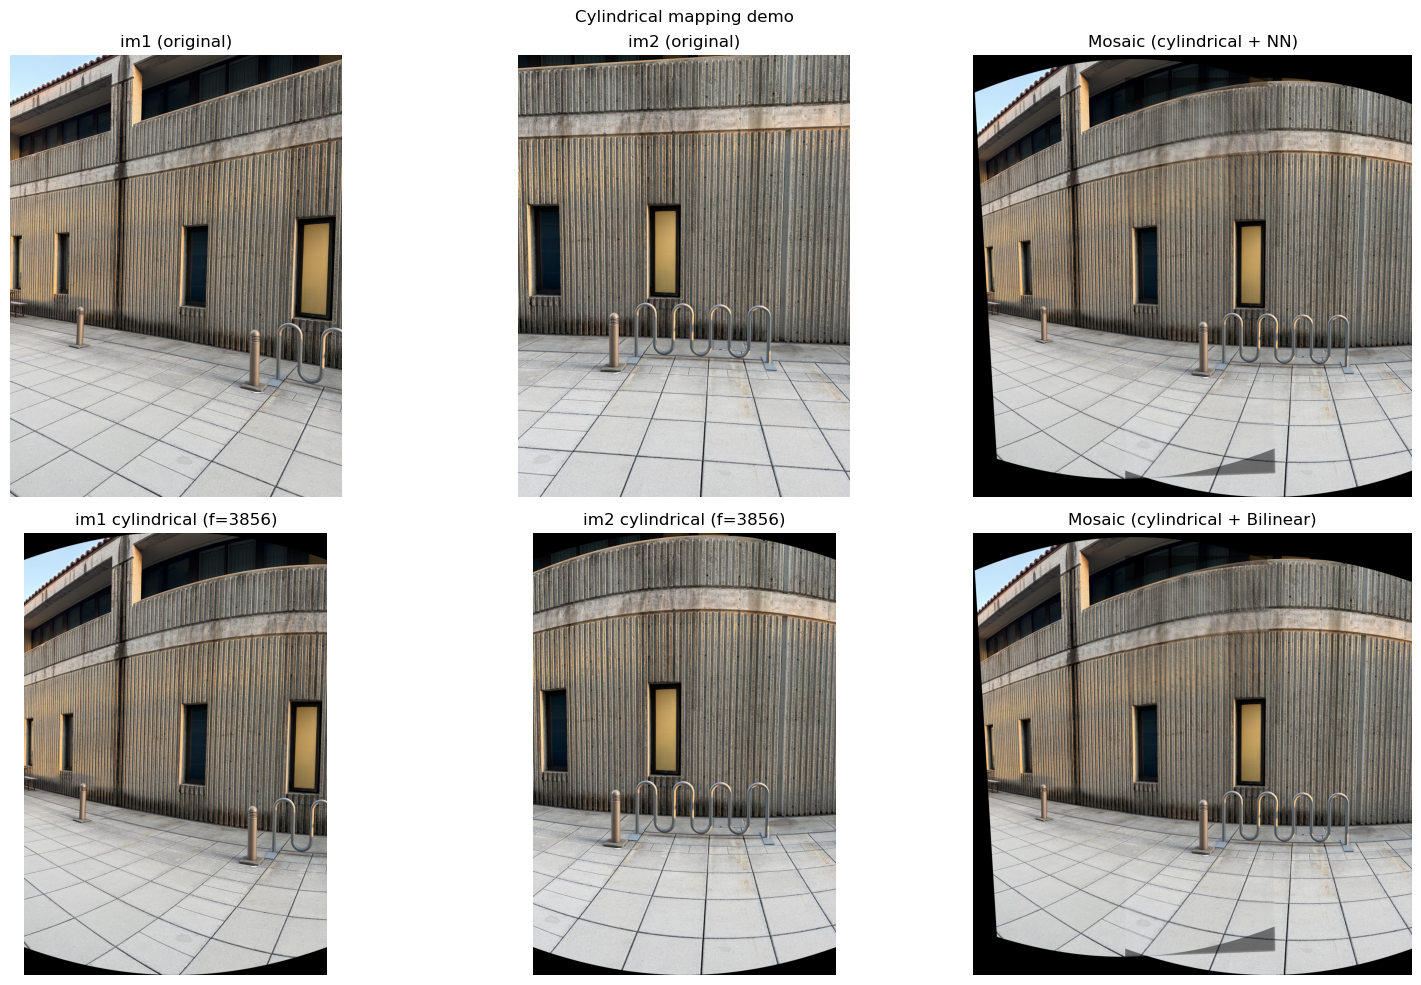

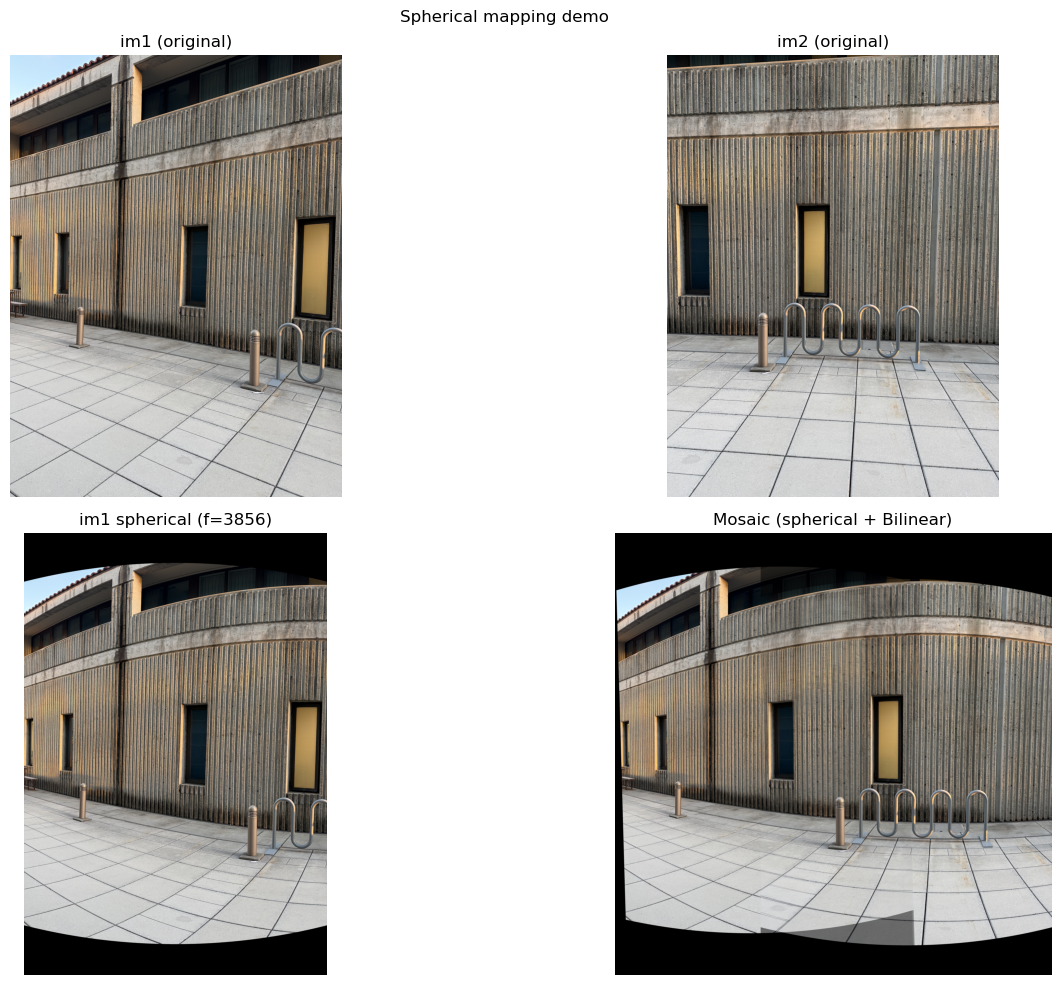

In [11]:
out_cyl = plot_cylindrical_mosaic(
    im1, im2,
    im1_pts=im1_pts, im2_pts=im2_pts,
    f_ratio=0.9, feather=True, falloff=60, gamma=1.2,
    show_nn=True,
    title_suffix="Cylindrical mapping demo"
)

out_sph = plot_spherical_mosaic(
    im1, im2,
    im1_pts=im1_pts, im2_pts=im2_pts,
    f_ratio=0.9, feather=True, falloff=60, gamma=1.2,
    show_nn=False,
    title_suffix="Spherical mapping demo"
)